In [30]:
#bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
import os
import sys
root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
src_path = os.path.join(root, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

from utils import verificaReviewScore

In [32]:
df = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv");

In [33]:
print(df.columns) 
#vou remover colunas de identificação, já que não afetam a avaliação
#'review_id', 'order_id'


Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')


In [34]:
df = df.drop(columns=['review_id', 'order_id']);
print(df.columns)

Index(['review_score', 'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp'],
      dtype='object')


In [35]:
print(df.info()) #verificando o tipe dos dados
#apenas um valor int: review_score
#review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp são colunas de palavras
#

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_score             99224 non-null  int64 
 1   review_comment_title     11568 non-null  object
 2   review_comment_message   40977 non-null  object
 3   review_creation_date     99224 non-null  object
 4   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None


In [36]:
#verificando quantos valores em branco em cada colunas
print(f"número de linhas: {df.shape[0]}\n")
for coluna in df.columns:
    print(f"coluna {coluna}, valores em branco: {df[coluna].isnull().sum()}")

número de linhas: 99224

coluna review_score, valores em branco: 0
coluna review_comment_title, valores em branco: 87656
coluna review_comment_message, valores em branco: 58247
coluna review_creation_date, valores em branco: 0
coluna review_answer_timestamp, valores em branco: 0


In [37]:
numeroDeLinhas = df.shape[0]
for coluna in df.columns:
    print(f"coluna {coluna}, percentual em branco: {((df[coluna].isnull().sum()/numeroDeLinhas) * 100):.2f}%")

coluna review_score, percentual em branco: 0.00%
coluna review_comment_title, percentual em branco: 88.34%
coluna review_comment_message, percentual em branco: 58.70%
coluna review_creation_date, percentual em branco: 0.00%
coluna review_answer_timestamp, percentual em branco: 0.00%


In [38]:
#vou elimar a coluna review_comment_title que tem quase 90% das linhas vazias, então acaba sendo inútil
df = df.drop(columns=['review_comment_title'])
print(df.columns)

Index(['review_score', 'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')


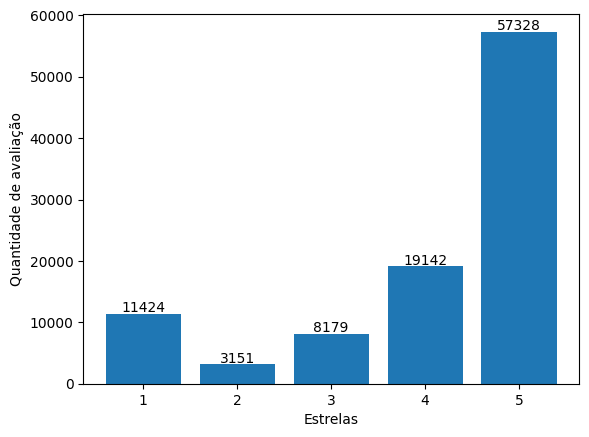

In [39]:
#vou conhecer melhor os dados:
#gráfico de quantidade de avalições para cada estrela (de 1 a 5 estrelas)
valores = df['review_score'].value_counts().sort_index()
plt.bar(valores.index, valores.values)

for i, v in enumerate(valores.values): #for para ver os valores exatos no gráfico
    plt.text(valores.index[i], v + 300, str(v), ha='center')

plt.xlabel('Estrelas')
plt.ylabel('Quantidade de avaliação')

plt.show()

#Então existem muito mais avaliações positivas do que negativas.

In [ ]:
#entendendo melhor o que fizeram as pessoas deram nota 5
"""
for index, estrela in enumerate(df['review_score']):
    if estrela == 5:
        if(pd.notnull(df['review_comment_message'][index])):
            print(df['review_comment_message'][index]+'\n')
""" #deixei comentado pois no github fica todos os comentários

#MUITOS comentários de entrega rápida

"\nfor index, estrela in enumerate(df['review_score']):\n    if estrela == 5:\n        if(pd.notnull(df['review_comment_message'][index])):\n            print(df['review_comment_message'][index]+'\n')\n"

In [2]:
#entendendo melhor o que fizeram as pessoas deram nota 1
"""
for index, estrela in enumerate(df['review_score']):
    if estrela == 1:
        if(pd.notnull(df['review_comment_message'][index])):
            print(df['review_comment_message'][index]+'\n')
""" #deixei comentado pois no github fica todos os comentários

#maioria das reclamações são de entrega(não entregues ou parcialmente entregues) ou de produtos errados e com defeitos
#MUITAS reclamações de entrega não realizada

"\nfor index, estrela in enumerate(df['review_score']):\n    if estrela == 1:\n        if(pd.notnull(df['review_comment_message'][index])):\n            print(df['review_comment_message'][index]+'\n')\n"

In [3]:
#entendendo melhor o que fizeram as pessoas deram nota 3
"""
for index, estrela in enumerate(df['review_score']):
    if estrela == 3:
        if(pd.notnull(df['review_comment_message'][index])):
            print(df['review_comment_message'][index]+'\n')
""" #deixei comentado pois no github fica todos os comentários

#maioria das reclamações são por demora de entrega, menos reclamações da qualidade do produto, alguns comentários positivos(?)

"\nfor index, estrela in enumerate(df['review_score']):\n    if estrela == 3:\n        if(pd.notnull(df['review_comment_message'][index])):\n            print(df['review_comment_message'][index]+'\n')\n"

# Possiveis Indicativos de Boas Avaliações:
- Entrega feita de forma rápida com certeza tem impacto na opinião do cliente;
- A entrega de vários produtos serem feitas juntas ajuda na melhor opinião do cliente;

# Possiveis Indicativos de Avaliações Ruins:
- Entrega não realizada; 
- Entrega feita por partes, ou seja, só um produto de mais entregue;
- Qualidade ruim ou produto não semelhante ao anunciado


In [43]:
#As 3 estrelas são meio peculiar, pois tem cometários ruins, majoritariamente referete a entrega e não ao produto em si. Algumas avaliações positivas são feitas aos produtos, então fica um ambiente com as opiniões misturadas.

print(f"porcetagens de valores com 3 estrelas: {((8179/df.shape[0])* 100):.2f}%") #Vendo a porcentagem de valores com 3 estrelas

#Por conta da nota 3 ser ambígua, com varios sentimentos e conter apenas 8% das avaliações, decidi remover as linhas que tenham essa avaliação. Assim mantando um padão mais fácil de destinguir entre notas positivas e notas negativas ajudando o modelo a perceber essas diferenças.


porcetagens de valores com 3 estrelas: 8.24%


In [44]:
df = df[df['review_score'] != 3] #3 estrelas removidas
print(df['review_score'].unique())

[4 5 1 2]


In [45]:
#como a coluna review_comment_message é a principal coluna que indica o levou o cliente a ter uma opinião positiva e negativa não posso apagar a coluna para tratar os valores vazios, e como 58% do dataframe está com esse valor vazio também não vou excluir as linha, se não perderia muita informação. Vou apenas substituir por um caracter vazio, que não vai afetar o CountVectorizer que penso em usar
df['review_comment_message'] = df['review_comment_message'].fillna('')

In [46]:
#vou colocar as avaliações com nota 5 e 4 como positivas e notas 1 e 2 como negativas.
df['Avaliação'] = df['review_score'].apply(verificaReviewScore) #essa função eu fiz no utils.py
print(df['review_score'].head(10))
print(df['Avaliação'].head(10))

0    4
1    5
2    5
3    5
4    5
5    1
6    5
7    5
8    5
9    4
Name: review_score, dtype: int64
0    Positiva
1    Positiva
2    Positiva
3    Positiva
4    Positiva
5    Negativa
6    Positiva
7    Positiva
8    Positiva
9    Positiva
Name: Avaliação, dtype: object


In [47]:
df.info() #ainda temos as colunas com datas, tive a ideia de pegar essas duas datas e criar uma só coluna com o tempo de resposta do vendendor. Com a hipótese de que um maior tempo de resposta pode levar o cliente a ter uma avaliação negativa

<class 'pandas.core.frame.DataFrame'>
Index: 91045 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_score             91045 non-null  int64 
 1   review_comment_message   91045 non-null  object
 2   review_creation_date     91045 non-null  object
 3   review_answer_timestamp  91045 non-null  object
 4   Avaliação                91045 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.2+ MB


In [48]:
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'])
df['review_answer_timestamp'] = pd.to_datetime(df['review_answer_timestamp'])

In [49]:
df['Tempo_de_Resposta'] = df['review_answer_timestamp']- df['review_creation_date']
df['Tempo_de_Resposta'].head(10) #lmebro que a avaliação 5 era a única dessas que foi negativa e também é a única que ta com um tempo de resposta de 3 dias

0   0 days 21:46:59
1   1 days 03:05:13
2   1 days 14:36:24
3   0 days 22:02:06
4   1 days 10:26:53
5   3 days 00:39:37
6   2 days 19:30:34
7   0 days 21:36:06
8   1 days 12:05:37
9   1 days 16:45:47
Name: Tempo_de_Resposta, dtype: timedelta64[ns]

In [50]:
df['Tempo_de_Resposta'] = (df['Tempo_de_Resposta'].dt.total_seconds()) /3600 #conversão para hora
df['Tempo_de_Resposta'].head(10)

0    21.783056
1    27.086944
2    38.606667
3    22.035000
4    34.448056
5    72.660278
6    67.509444
7    21.601667
8    36.093611
9    40.763056
Name: Tempo_de_Resposta, dtype: float64

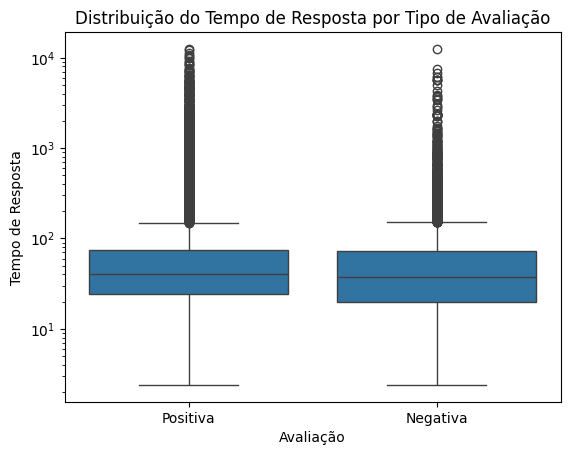

In [51]:

sns.boxplot(x='Avaliação', y='Tempo_de_Resposta', data=df)
plt.title('Distribuição do Tempo de Resposta por Tipo de Avaliação')
plt.ylabel('Tempo de Resposta')
plt.yscale('log')
plt.xlabel('Avaliação')
plt.show()
#não ficou muito fácil de perceber a diferença no boxplot, os dados são bem parecidos até

In [52]:
print(df.groupby('Avaliação')['Tempo_de_Resposta'].describe())
#O tempo de resposta na vedade é menor para as avaliações ruins, acabou indo contra a minha hpótese inicial
#Vou manter a coluna mesmo assim, para ver se ajuda o modelo a aprender

             count       mean         std       min        25%        50%  \
Avaliação                                                                   
Negativa   14575.0  72.975675  235.471166  2.406667  19.682778  37.977500   
Positiva   76470.0  76.502224  245.433813  2.421944  24.549583  40.417917   

                 75%           max  
Avaliação                           
Negativa   72.602778  12448.781111  
Positiva   74.701875  12303.793611  


In [53]:
df = df.drop(columns=['review_creation_date', 'review_answer_timestamp']) #removi as colunas de datas que não vão ser mais usadas.

In [54]:
df = df.reset_index(drop=True) #Arrumando os index

In [56]:
df.isnull().sum()

review_score              0
review_comment_message    0
Avaliação                 0
Tempo_de_Resposta         0
dtype: int64

In [55]:
df.to_csv('../data/processed/order_revies_processed.csv', index=False)